In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
combined_df = pd.read_csv("../../data/features.csv")
combined_df.columns = combined_df.columns.astype(str)


X = combined_df.drop(columns=['Cancerous', 'ID', 'Unnamed: 0'], errors='ignore')
y = combined_df['Cancerous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

n_estimators = 1 - train_acc: 0.825 - val_acc: 0.600
n_estimators = 10 - train_acc: 0.978 - val_acc: 0.650
n_estimators = 25 - train_acc: 0.998 - val_acc: 0.630
n_estimators = 50 - train_acc: 1.000 - val_acc: 0.660
n_estimators = 100 - train_acc: 1.000 - val_acc: 0.650
n_estimators = 250 - train_acc: 1.000 - val_acc: 0.650

max_depth_metrics = 3 - train_acc: 0.720 - val_acc: 0.650
max_depth_metrics = 4 - train_acc: 0.723 - val_acc: 0.650
max_depth_metrics = 5 - train_acc: 0.800 - val_acc: 0.640
max_depth_metrics = 6 - train_acc: 0.805 - val_acc: 0.610
max_depth_metrics = 7 - train_acc: 0.860 - val_acc: 0.610
max_depth_metrics = 8 - train_acc: 0.900 - val_acc: 0.580
max_depth_metrics = None - train_acc: 0.978 - val_acc: 0.650


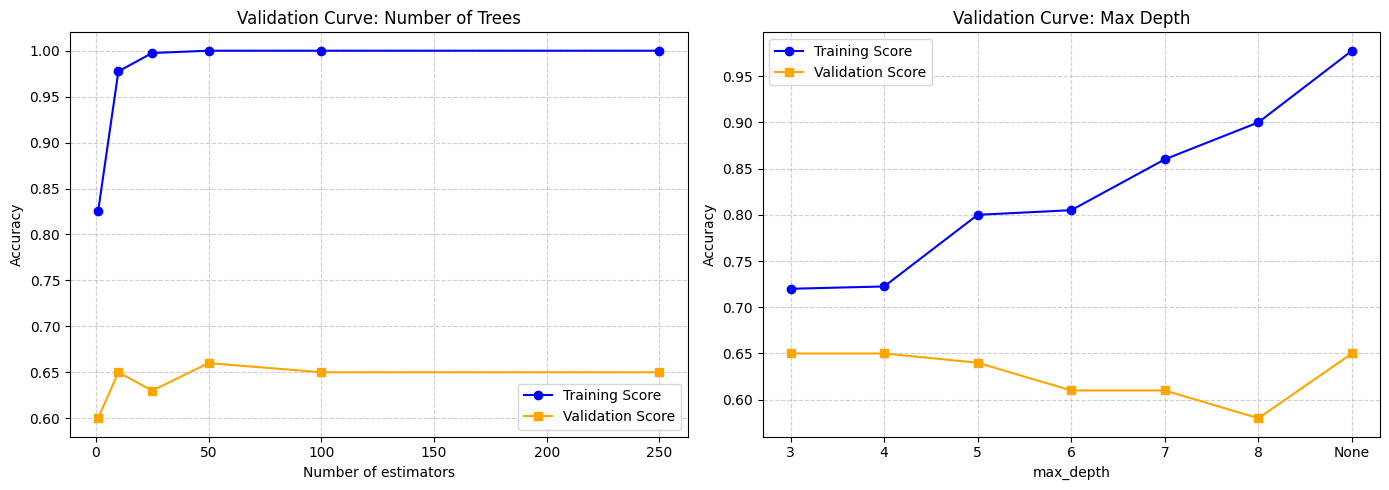

In [4]:
n_est_metrics = {"train":[], "val":[]}
max_depth_metrics = {"train":[], "val":[]}
n_estimator = [1, 10, 25, 50, 100, 250]
depth_list = [3, 4, 5, 6, 7, 8, None]

for n in n_estimator:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    val_acc = rf.score(X_test, y_test)
    n_est_metrics["train"].append(train_acc)
    n_est_metrics["val"].append(val_acc)
    print(f"n_estimators = {n} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")

print("")
for d in depth_list:
    rf = RandomForestClassifier(n_estimators=10, class_weight='balanced', random_state=42, max_depth=d)
    rf.fit(X_train, y_train)
    train_acc = rf.score(X_train, y_train)
    val_acc = rf.score(X_test, y_test)
    max_depth_metrics["train"].append(train_acc)
    max_depth_metrics["val"].append(val_acc)
    print(f"max_depth_metrics = {d} - train_acc: {train_acc:.3f} - val_acc: {val_acc:.3f}")



# Set up a wide canvas with 2 side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Number of Trees (n_estimators) ---
ax[0].plot(n_estimator, n_est_metrics["train"], marker='o', label="Training Score", color="blue")
ax[0].plot(n_estimator, n_est_metrics["val"], marker='s', label="Validation Score", color="orange")
ax[0].set_title("Validation Curve: Number of Trees")
ax[0].set_xlabel("Number of estimators")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

# --- PLOT 2: Maximum Depth (max_depth) ---
# Convert 'None' to a string so matplotlib can plot it on the x-axis
depth_labels = [str(d) for d in depth_list]

ax[1].plot(depth_labels, max_depth_metrics["train"], marker='o', label="Training Score", color="blue")
ax[1].plot(depth_labels, max_depth_metrics["val"], marker='s', label="Validation Score", color="orange")
ax[1].set_title("Validation Curve: Max Depth")
ax[1].set_xlabel("max_depth")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

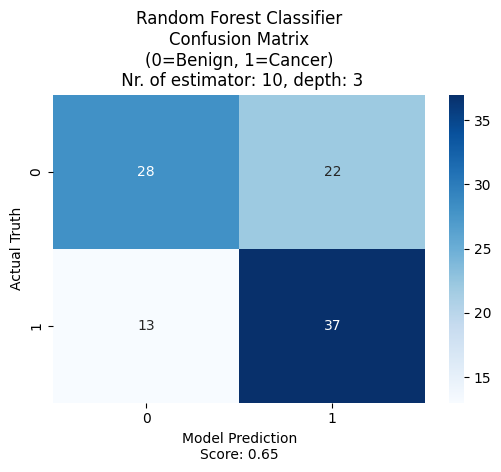

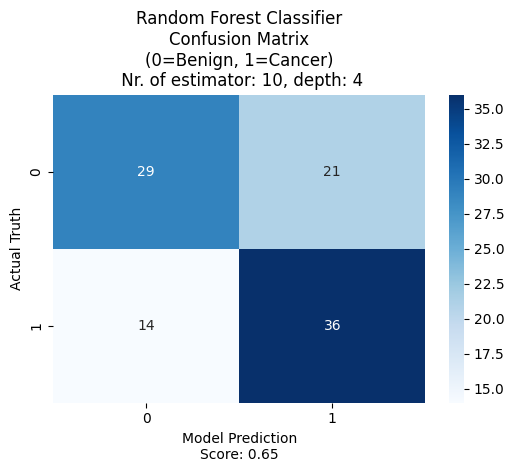

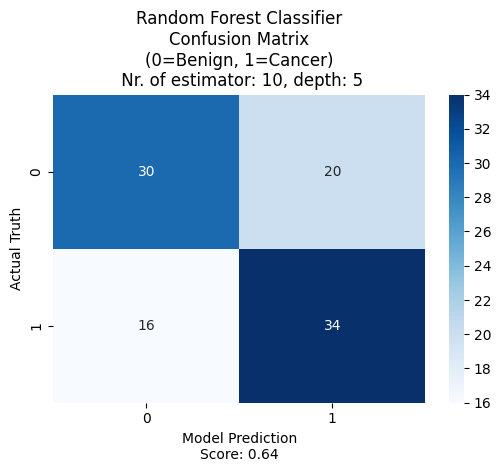

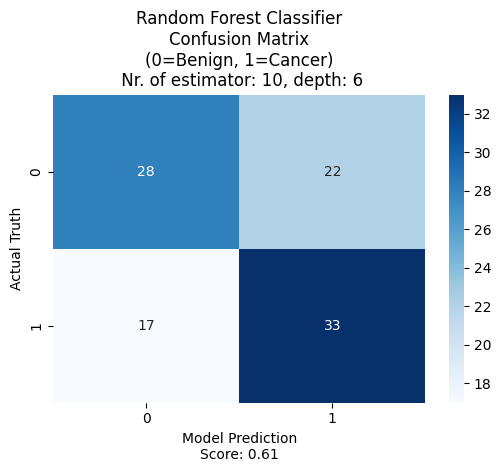

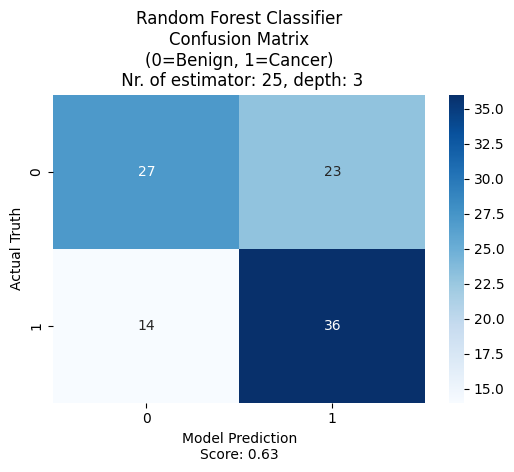

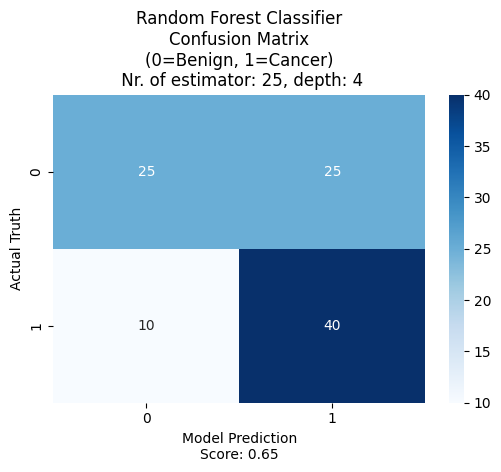

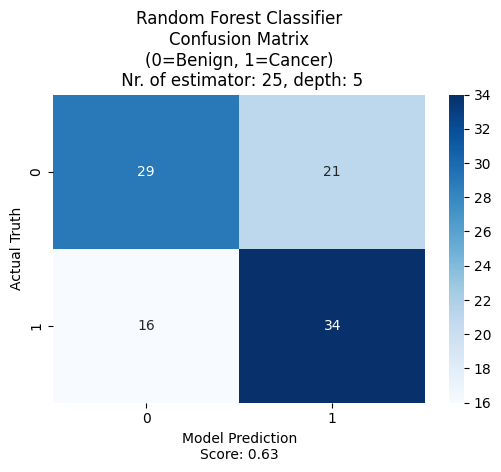

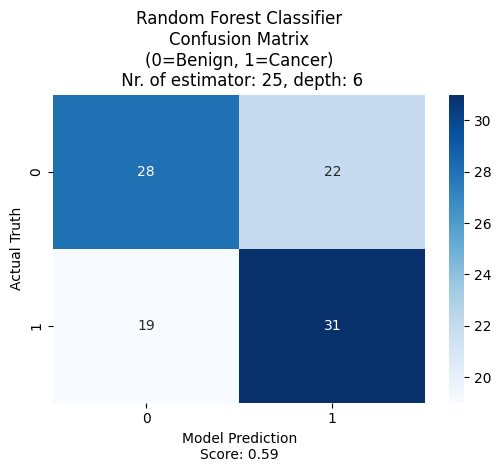

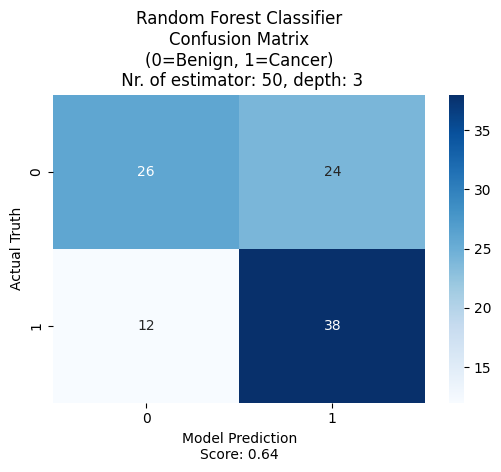

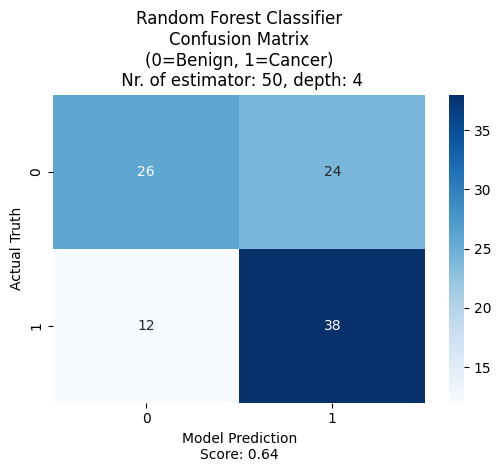

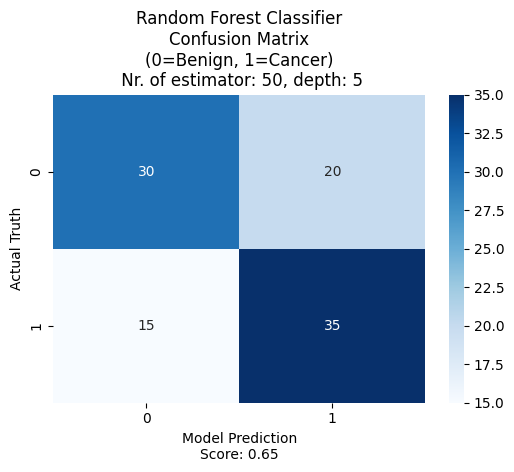

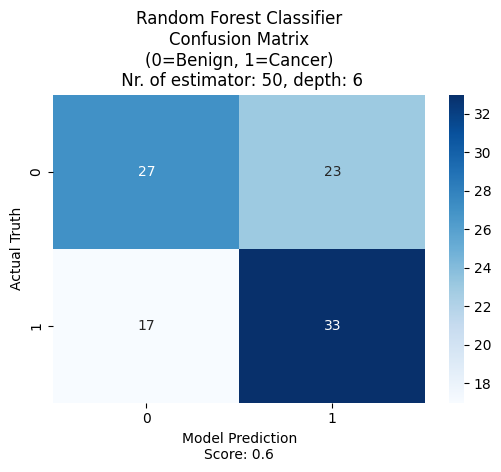

In [8]:
final_estimators = [10, 25, 50]
final_depth = [3, 4, 5, 6]

for n in final_estimators:
    for d in final_depth:

        # Train the Forest
        rf_final = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=42, max_depth=d)
        rf_final.fit(X_train, y_train)

        # Predict and Evaluate
        final_preds = rf_final.predict(X_test)
        # print(f"\nFinal Accuracy: {accuracy_score(y_test, final_preds):.3f}")
        # print(classification_report(y_test, final_preds))

        # Draw the Confusion Matrix
        plt.figure(figsize=(6,4))
        sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues')
        plt.title(f"Random Forest Classifier\nConfusion Matrix\n(0=Benign, 1=Cancer)\n Nr. of estimator: {n}, depth: {d}")
        plt.ylabel('Actual Truth')
        plt.xlabel(f'Model Prediction\nScore: {rf_final.score(X_test, y_test)}')
        plt.savefig(f"../predictions/random_forest_classifier/conf_matrix_{n}_estim_{d}_depth.png", dpi = 200, bbox_inches = "tight")
        